#  Project Stage II — Statistical Analysis

### Reload the newdataset you saved in stage I, this stage we will explore statistical analysis and propose Hypothesis questions.

### Task 1- Descriptive Statistics (20 points)

Review the features you explored in stage I (at least 3 features per team, at least two features are numerical - continuous/discrete); if there is no numerical feature, revisit the original dataset and select a suitable and meaningful numerical feature. Categorical features can still be included, but they must be encoded into numeric form (e.g., gender → 0/1)

a. Cacluate the selected features mean, median, variance, skewness and kurtosis. (10 points)

b.Identify the type of data: categorical or numerical. If numerical, is it continuous or discrete? Summarize your findings. (10 points)  

**Temperature, Precipitation and Visibility are numerical and continuous variables. Temperature is a measured value in fahrenheit. Precipitation is a measured value of rainfall in inches. Visiblity is a measured value in miles that indicates field of sight.**


In [996]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/newdata.csv")

# Temperature, Precipitation, Visibility
# Calculate the means, medians, variances, skewness, and kurtosis
features = ['Temperature(F)', 'Precipitation(in)', 'Visibility(mi)']

stats_df = pd.DataFrame({
    'Mean': [df[col].mean() for col in features],
    'Median': [df[col].median() for col in features],
    'Variance': [df[col].var() for col in features],
    'Skewness': [df[col].skew() for col in features],
    'Kurtosis': [df[col].kurt() for col in features]
}, index=features)

print(stats_df.round(4))

                      Mean  Median  Variance  Skewness  Kurtosis
Temperature(F)     66.6308    66.0  158.8358    0.1055    0.1947
Precipitation(in)   0.0019     0.0    0.0002   14.1515  275.2445
Visibility(mi)      9.3505    10.0    3.4652   -1.7191   19.2774


### Task 2 - Distribution Fitting (20 points)

a. Select one suitable numerical feature from task 1.  Propose a theoretical distribution (Normal, Binomial, Poisson, Exponential, Geometric, etc.) and explain why you choose it. (6 points)   

**Feature: Temperature  
Theoretical Distribution: Normal Gaussian  
Why: Temperature is a continuous numerical variable. Temperature can be a value within a range. Most values cluster around the mean.   
Skewness = 0.1055 is close to 0 which indicates symmetry and no/minimal skewnes,   
Kurtosis = 0.1947 is close to 0 which indicates normal tailedness and extent of outliers,   
Mean = 66.6 and Median = 66.0 which indicates symmetry.**      

b. Plot histogram of your feature, overlay a smooth curve of the fitted theoretical distribution (10 points). Discuss how your data fits the distribution. (4 points)

**The histogram follows the bell shaped curve and shows that the data is symmetric with minimal skewness. The peak of the distribution aligns well with the theoretical curve. Temperature fits the normal distribution curve and the near zero skewness/kurtosis confirms that normal distribution fits this data.**

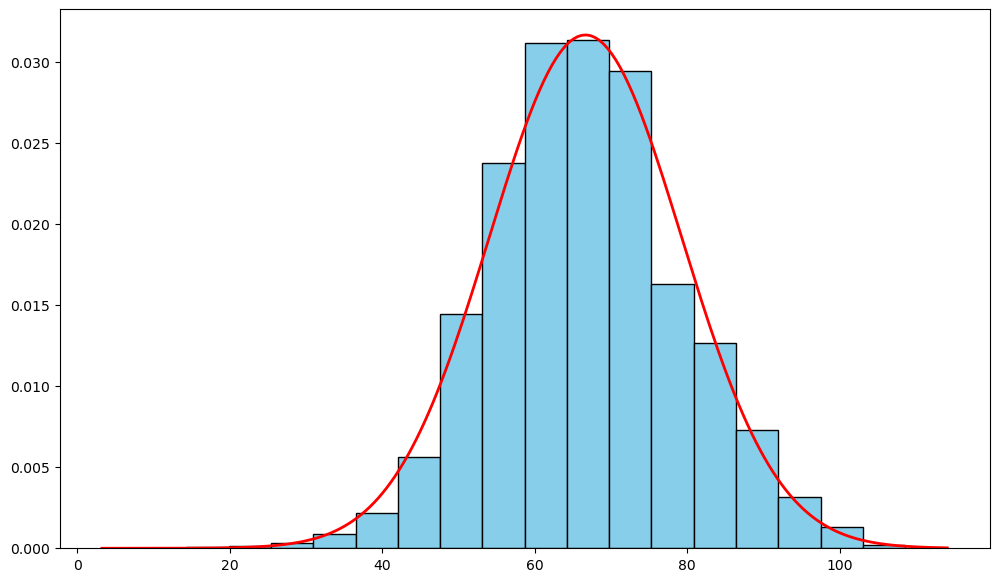

In [999]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Plot histogram of Temperature feature
temperature_data = df['Temperature(F)']
temp_mean = temperature_data.mean()
temp_stdev = temperature_data.std()

plt.figure(figsize=(12,7))
plt.hist(temperature_data, bins=20, density=True, ec='black', range=(temperature_data.min(),temperature_data.max()), color='skyblue', label='Temperature(F) Data')

# Overlay fitted normal distribution curve
x = np.linspace(temperature_data.min(), temperature_data.max(), 200)
fitted_curve = stats.norm.pdf(x, temp_mean, temp_stdev)
plt.plot(x, fitted_curve, 'r-', linewidth=2, label='Fitted Normal Distribution')

### Task 3 - Point Estimate (20 points)

a. Randomly select 100 samples from the feature selected in Task 2, caculate the sample mean and variance. Compare with the population mean and variance. (10 points)

In [1002]:
sample1 = temperature_data.sample(n=100, random_state=42)

print('Sample 1 mean:', sample1.mean(), 'Sample 1 variance:', sample1.var())

Sample 1 mean: 66.194 Sample 1 variance: 153.75572121212116


**As seen in task 1, the population mean and variance for the temperature feature are 66.6308 and 158.8358 in that order. The population mean (66.6308) is almost identical to the sample mean (66.194). The population variance was also very similar to the sample variance but was off by about 5.**

b. Repeat the random sampling 3 times and show how sample mean/variance vary due to randomness. Discuss your findings. (10 points)

In [1005]:
sample2 = temperature_data.sample(n=100, random_state=41)
sample3 = temperature_data.sample(n=100, random_state=40)
sample_df = pd.concat([sample1, sample2, sample3], axis = 1)

sample_df.columns = ['Sample 1', 'Sample 2', 'Sample 3']

sample_stats = pd.DataFrame({
    'Mean': [sample_df[col].mean() for col in sample_df.columns],
    'Variance': [sample_df[col].var() for col in sample_df.columns],
}, index=sample_df.columns)

sample_stats

,Mean,Variance
Sample 1,66.194,153.755721
Sample 2,64.723,138.221587
Sample 3,67.474,141.659519


**It is apparent that the mean values for the random samples are reasonably close to the population mean while the sample variances have a larger difference from the population. The means vary within about 2 degrees from the population mean while the variences spread across a wider range of about 20.**

### Task 4 - Correlation Analysis (20 points)

Among the features in task 1, calculate the correlation coefficients. Use a heatmap or correlation matrix for visualization.

In [1009]:
correlation_matrix = stats_df.corr()
correlation_matrix

,Mean,Median,Variance,Skewness,Kurtosis
Mean,1.000000,0.999939,0.993863,-0.521231,-0.656149
Median,0.999939,1.000000,0.992576,-0.530660,-0.664475
Variance,0.993863,0.992576,1.000000,-0.423629,-0.568647
Skewness,-0.521231,-0.530660,-0.423629,1.000000,0.986019
Kurtosis,-0.656149,-0.664475,-0.568647,0.986019,1.000000


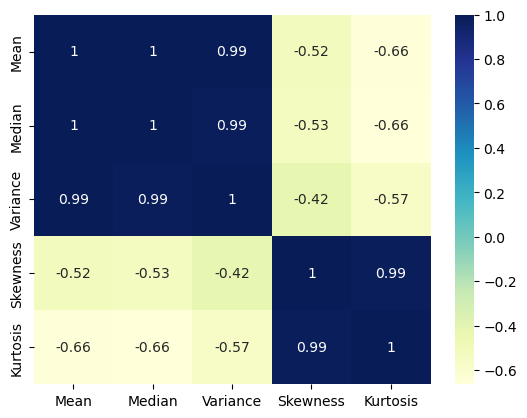

In [1010]:
import seaborn as sns

sns.heatmap(correlation_matrix, cmap = "YlGnBu", annot=True)

plt.show()

### Task 5 - Hypothsis Question Propose. (20 points)

Formulate 3 hypothsis questions based on your whole data. Choose 3 different variables to compare against.

For example:   Does higher employment data lead to higher covid case? The variable here is employment data. 

Make sure your hypothsis questions are meaningful, since we will test on it in next stage.

**The 3 hypothesis questions we choose and their variables are as follows**
- **Does a longer accident duration lead to a higher accident severity? For this question we will look at Start_Time, End_Time, and Severity.**
- **Are accidents near traffic signals, juntions, railways or crossings more severe than those occuring else where? For this one we will compare against Severity, Traffic_Signal, Junction, Crossing, and Railway.**
- **Does weather effect the severity of an accident? Here we will look at temperature, percipitation, visibility, and severity.**

**These questions will help determine what aspects of our traffic data are likely to increase the severity of accidents. Understanding this information could potentially help prevent more severe accidents.**

Upload your notebook in Github and a pdf/html version in canvas. Make sure all the figures are clearly shown in your submission.

Prepare slide for the mid-term presentation, all teams need to present the first 2 stages of your project. Each group will be assigned at most 15 minutes. 